## Eval 2

The goal of this evaluation is to solve six optimization problem (whose oracles are given) using the algorithms you have seen so far in the practical sessions. You can freely re-use your notes and implemented algorithms from the previous practical sessions. 

When working on problem number $i$, you should:
- look into the file `problemi.py` to observe the properties of the problem at hand, 
- select which algorithm is, in your opinion, best suited for this problem based on these properties,
- justify this choice,
- run the algorithm,
- comment on the observed performance.

Initialise the algorithms from $x_0 = 0$. If for some reason, you need an alternative initialization, explain why this is the case and include the run initialized at $x_0 = 0$. You can only use the provided oracles `f` and `grad_f`, and you may have to implement additional projection and proximity operators. If you perform some pen-and-paper calculations, you do not have to write down all the details in the notebook: just explain what you were trying to compute, how you computed it, and the result you obtained. The choice of hyper-parameters (stopping criterion, step-size,...) is up to you and should be justified.

At the end of the session (i.e., before 11:15), send me an email to `thomas.guilmeau@inria.fr` with object `NumOpt - eval2 - yourFirstName_yourSurname` with an attached archive named `yourFirstName_yourSurname` containing this notebook with your explainations and runs, the problem files, the `utils.py` file, as well as the `algorithms.py` files that you have used. I should be able to run your notebook again and obtain the same results as you.

*Some advice:*

If you realise that maybe another algorithm is a better choice, or if you think that two algorithms may have similar performance, you can explain why you think so, run both algorithms, and compare their performance. Some problems are harder than others, so if you do not manage to solve exactly the problem, you can explain why the algorithms you have considered do not work and move on to the next problems.

In [1]:
from utils import *
from algorithms import *

%load_ext autoreload
%autoreload 2

### Problem 1

Minimize the quadratic function defined by $f(x) = \frac{1}{2}x^\top A x + b^\top x + c$ where $A \succ 0$, $b \in \mathbb{R}^d$, and $c \in \mathbb{R}$ using only the noisy oracle `grad_f`, which returns 
$$
\nabla f(x) + n
$$
for every $x \in \mathbb{R}^d$. Here, $n$ is distributed following a standard Gaussian distribution. Yo uare also given an exact oracle `f` of $f$.

For this problem, you can only use a maximum number of $K = 250$ iterations.

------------------------------------
 Adam 
------------------------------------
START
FINISHED -- 249 iterations -- 0.383859s -- final value: 0.857761




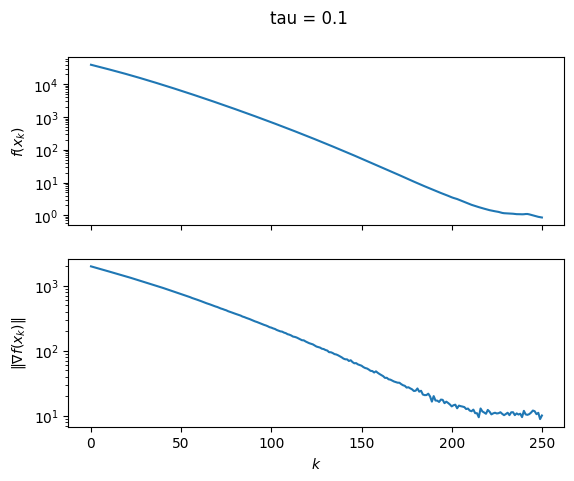

In [2]:
import problem1 as pb1

iterMax = 250
x_init = np.zeros(pb1.d)   
tau = 0.1
x_adam, x_adam_tab = adam(pb1.f, pb1.grad_f, x_init, tau, 0.9, 0.999, 0.000001, iterMax)
plot_obj_normGrad(x_adam_tab, pb1.f, pb1.grad_f, f"tau = {tau}")

As this is some noisy data, we can use adaptive methods like adam and adagrad. As Adam is more advanced, incorporating momentum, we will use it.
As we only have a small amount of iteration, we choose a big step size tau = 0.1.

### Problem 1 bis

Consider again the optimization problem given in Problem 1, but this time, you can only use a maximum number of $K = 3000$ iterations.

Because we have more iteration we reduced tau by 10.

------------------------------------
 Adam 
------------------------------------
START
FINISHED -- 2999 iterations -- 6.139763s -- final value: 0.089250




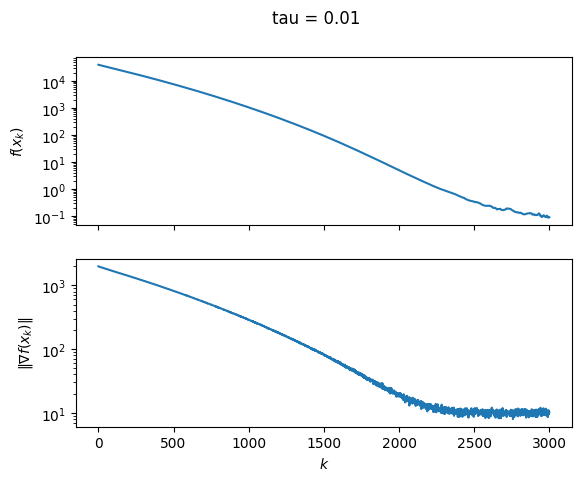

In [3]:
iterMax = 3000
x_init = np.zeros(pb1.d)   
tau = 0.01
x_adam, x_adam_tab = adam(pb1.f, pb1.grad_f, x_init, tau, 0.9, 0.999, 0.000001, iterMax)
plot_obj_normGrad(x_adam_tab, pb1.f, pb1.grad_f, f"tau = {tau}")

### Problem 1 ter

Consider again the optimization problem given in Problem 1, but this time, you can only use a maximum number of $K = 10000$ iterations.

Again we further reduced tau.

------------------------------------
 Adam 
------------------------------------
START
FINISHED -- 9999 iterations -- 34.169821s -- final value: 0.474465




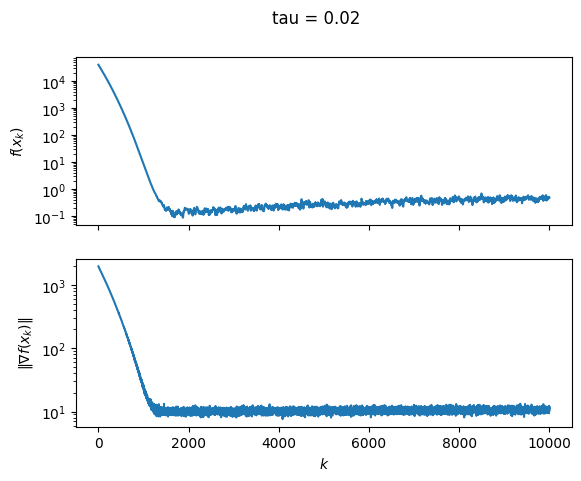

In [4]:
iterMax = 10000
x_init = np.zeros(pb1.d)   
tau = 0.02
x_adam, x_adam_tab = adam(pb1.f, pb1.grad_f, x_init, tau, 0.9, 0.999, 0.000001, iterMax)
plot_obj_normGrad(x_adam_tab, pb1.f, pb1.grad_f, f"tau = {tau}")

### Problem 2

Minimize the function $f : \mathbb{R}^d \rightarrow \mathbb{R}$ over $\mathbb{R}^d$, using only the noisy oracle `grad_f` of $\nabla f$. For any $x \in \mathbb{R}^d$, this oracles returns
$$
\nabla f(x) + n,
$$
where $n$ follows a $d$-dimensional standard Student-t distribution with $2$ degrees f freedom (such a distribution is called *heavy-tailed*, and corresponds to a high-noise regime).

Here, the objective function $f$ is defined by
$$
f(x) = \log\left( 1 + \frac{1}{\nu}(x - \mu)^\top \Sigma^{-1}(x-\mu) \right)
$$
with $\nu > 0$, $\Sigma \succ 0$, and $\mu \in \mathbb{R}^d$, and you are also given an exact oracle of $f$.

In [5]:
import problem2 as pb2

Again as the data is noisy we use adam.

------------------------------------
 Adam 
------------------------------------
START
FINISHED -- 9999 iterations -- 0.573052s -- final value: 7.212676




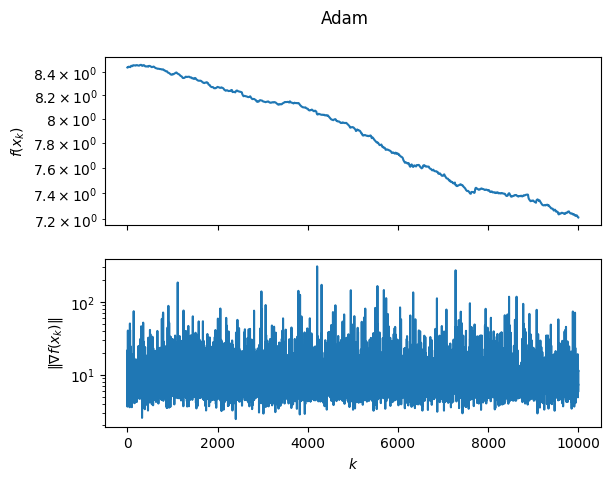

In [6]:
iterMax = 10000
x_init = np.zeros(pb2.d)   
tau = 0.01
x_adam, x_adam_tab = adam(pb2.f, pb2.grad_f, x_init, tau, 0.9, 0.999, 0.000001, iterMax)
plot_obj_normGrad(x_adam_tab, pb2.f, pb2.grad_f, "Adam")

### Problem 3

Minimize $F = f + g$ on $\mathbb{R}^d$ where
\begin{align*}
    f(x) &= \sum_{i=1}^d f_i(x_i),\\
    g(x) &= \max \{ \|x\|_2 -\epsilon, 0 \}.
\end{align*}
For any $i \in \{1,\dots,d\}$, the function $f_i : \mathbb{R} \rightarrow \mathbb{R}$ is defined by
$$
f_i(x_i ) = \delta_i^2 \left(  \sqrt{1 + (x_i / \delta_i)^2} - 1 \right)
$$
where $\delta_i > 0$. Exact oracles for evaluating $f$, $g$, $F$, and $\nabla f$ are given.

The following formula is also given for any $\tau > 0$:
$$
\textrm{prox}_{\tau g}(x) = 
\begin{cases}
    x &\textrm{ if } \|x\|_2 - \epsilon \leq 0\\
    \frac{\epsilon}{\| x \|_2} x &\textrm{ if } 0 < \|x \|_2 - \epsilon \leq \tau\\
    \left(1 - \frac{\tau}{\|x \|_2} \right)x &\textrm{ otherwise}.
\end{cases}
$$

In [7]:
import problem3 as pb3

Here the problem is plit into a smooth and a non smooth function, so we have to use proximal gradient.

In [8]:
eps = pb3.epsilon
def prox_g(x, tau):
    if np.linalg.norm(x)- eps <= 0:
        return x
    elif 0 < np.linalg.norm(x)-eps < tau:
        return (eps/np.linalg.norm(x))* x
    else : return (1-tau/np.linalg.norm(x))*x

------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 2346 iterations -- 0.252578s -- final value: 57.456844 




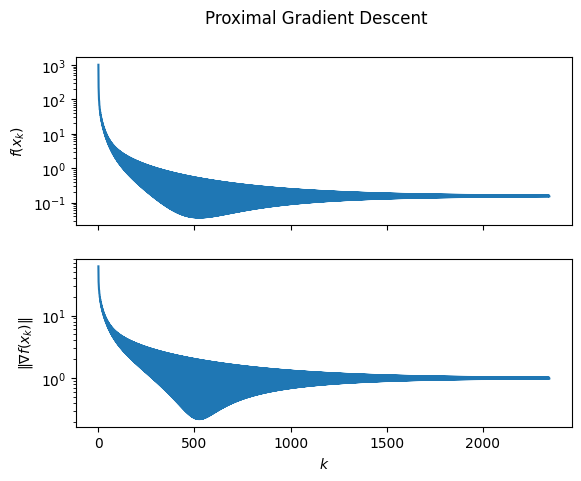

In [9]:
from utils import *
from algorithms import *
tau = 1.
x_init = np.zeros(pb3.d)
x, x_tab = prox_grad(pb3.F, pb3.grad_f, prox_g, x_init, tau, iterMax=10000, prec=pb3.epsilon)
plot_obj_normGrad(x_tab, pb3.f, pb3.grad_f, "Proximal Gradient Descent")

### Problem 4

Find a point that belongs to $C_1 \cap C_2 \cap C_3$, where $C_i = \{ x \in \mathbb{R}^d,\,a_i^\top x \leq b_i\}$ and
$$
\textrm{proj}_{C_i}(x) = x + \frac{\min \{0, b_i - a_i^\top x \}}{\|a_i\|_2^2} a_i
$$
for $i \in \{1,2\}$, and where $C_3 = \{x \in \mathbb{R}^d,\, x\top x \leq 1 \}$ with
$$
\textrm{proj}_{C_3}(x) = \frac{1}{\max \{ 1, \| x \| \}} x.
$$
You have access to the vectors $a_1, a_2 \in \mathbb{R}^d$ and to the scalars $b_1, b_2 \in \mathbb{R}$.

As all the $C_i$ are convex sets, and we search a projection on all of them, we use the Projection Onto Convex Sets algorithm (POCS).

In [10]:
from problem4 import a1, a2, b1, b2
print(a1,a2, b1, b2)
def proj_c1(x):
    return x + np.min((0, (b1-a1.T@x)/(np.linalg.norm(a1)**2)))*a1
def proj_c2(x):
    return x + np.min((0, (b2-a2.T@x)/(np.linalg.norm(a2)**2)))*a2
def proj_c3(x):
    return (1/np.max((1, np.linalg.norm(x))))*x
def proj(x):
    return proj_c3(proj_c2(proj_c1(x)))

[0.74888099 0.18714588 0.38587406 0.49936548 0.60221604 0.71224485
 0.85728886 0.83885272 0.37919539 0.27872344] [0.72433086 0.99606714 0.16759719 0.10241888 0.74535603 0.42536334
 0.80014412 0.82527273 0.76535689 0.29148581] 0.10771887400478186 0.8743593143693272


In [11]:
import problem4 as pb4
x_init = np.random.random(pb4.d)
x, x_tab = POCS(proj, x_init, iterMax=1000)
print(f"x_init = {x_init}")
print(f"x* = {x}")
print(f"proj_c1(x*) = {proj_c1(x)}")
print(f"proj_c2(x*) = {proj_c2(x)}")
print(f"proj_c3(x*) = {proj_c3(x)}")
print(f"proj(x*) = {proj(x)}")

------------------------------------
 POCS 
------------------------------------
START
FINISHED -- 999 iterations -- 0.019660s 


x_init = [0.96736147 0.9277674  0.24851393 0.13552987 0.78367146 0.43460046
 0.38633882 0.20292185 0.39498748 0.56656446]
x* = [ 0.35757357  0.67164959 -0.02981597 -0.19876421  0.289159   -0.0785331
 -0.22007643 -0.36923362  0.08982312  0.31307523]
proj_c1(x*) = [ 0.35757357  0.67164959 -0.02981597 -0.19876421  0.289159   -0.0785331
 -0.22007643 -0.36923362  0.08982312  0.31307523]
proj_c2(x*) = [ 0.35757357  0.67164959 -0.02981597 -0.19876421  0.289159   -0.0785331
 -0.22007643 -0.36923362  0.08982312  0.31307523]
proj_c3(x*) = [ 0.35757357  0.67164959 -0.02981597 -0.19876421  0.289159   -0.0785331
 -0.22007643 -0.36923362  0.08982312  0.31307523]
proj(x*) = [ 0.35757357  0.67164959 -0.02981597 -0.19876421  0.289159   -0.0785331
 -0.22007643 -0.36923362  0.08982312  0.31307523]


we changed the initial condition from 0, as this was already a solution.
We can see that at the end we obtain a point that is part of all the projections

### Problem 5

Minimize the function $f : \mathbb{R}^d \rightarrow \mathbb{R}$ defined by $f(x) = c^\top x$, where $c \in \mathbb{R}^d$, over the set $C = \{ x \in \mathbb{R}^d,\, \| x \|_2 \leq 1 \}$, which coincides with the set $C_3$ from Problem 4. You can use the oracles `f` and `grad_f` which can be used to evaluate (exactly) $f$ and $\nabla f$.

In [12]:
import problem5 as pb5

Here we can use the projected gradient algorithm.

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 10 iterations -- 0.000346s -- final value: 0.000000 -- final gradient norm: 13.807120 




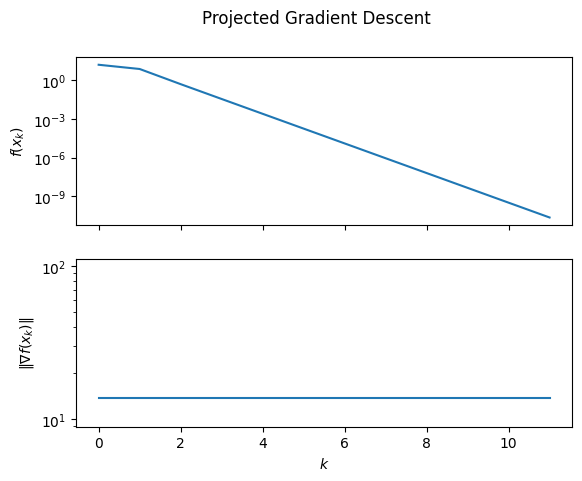

In [13]:
x_init = np.random.random(pb5.d)
tau = 0.2
iterMax=5000
prec = 1e-6

x,x_tab = proj_GD(pb5.f, pb5.grad_f, proj_c3, x_init, tau, iterMax, prec)
plot_obj_normGrad(x_tab, pb5.f, pb5.grad_f, "Projected Gradient Descent")